In [37]:
import numpy as np
import matplotlib.pyplot as plt

class InstrumentsOfProduction:
    
    def __init__(self, out_index, productivity, material_input):
        
        self.out_index = out_index # What product is made
        self.productivity = productivity # What is the productivity, quantity/labor-time
        
        self.material_input = material_input # What is the vector of material input to product 1 unit of output product
        
        # What is the fixed stock associated with these instruments
        self.FixedStock = np.array([1, 0., 0.])
        
        # How many people can work on the instruments
        self.Nmax = 10
        
        # How many people are required at minimum to work on the instruments
        self.Nmin = 1
        
        # Unit vector
        unit_vector = np.zeros(N_products)
        unit_vector[out_index] = 1
        
        self.unit_vector = unit_vector
        
    def produce(self, labor_activity):
        
        return self.productivity * labor_activity * self.unit_vector
        
        
class UnitOfProduction:
    
    def __init__(self, out_index, productivity, material_input, *, tolerance=1e-6):
        
        self.out_index = out_index # The index of the output product
        
        # Initialize the instruments
        self.Instruments = InstrumentsOfProduction(out_index, productivity, material_input)
        
        # What is the stock of objects of labor (material inputs) that the unit has on hand?
        self.ObjectsOfLabor = np.array([0.5, 0.0, 0.0])
        
        self.tolerance = tolerance
        
        
    def produce(self, N, h):
        
        # The labor activity level (labor-time per day) (L)
        labor_activity = N*h

        # The desired activity level vector (quantity produced per day) (q)
        activity_vector = self.Instruments.produce(labor_activity)

        # The scalar of the activity level
        activity_scalar = activity_vector[self.out_index]

        # This desired activity level will decrease the stock of material to the following...
        # We need to check that there is enough stock to produce this activity, else we adjust the activity level
        depletion = self.ObjectsOfLabor - self.Instruments.material_input*activity_scalar*dt

        if np.any(depletion < 0):

            # Calculate the possible adjusted activities
            # These are potential activities that ensure the stocks of material inputs are not reduced to a negative
            adjusted_activities = (self.ObjectsOfLabor[depletion < 0])/(self.Instruments.material_input[depletion < 0]*dt)

            # There may be many potential adjusted activity levels
            # Pick the smallest of the above adjusted activities, to ensure that no stock is reduced below zero
            adjusted_activity = np.min(adjusted_activities)

            # The actual laboring hours to get this new adjusted activity have been reduced to...
            h = adjusted_activity/N

            # Now using the above hours, enact production

            # The new labor activity
            labor_activity = N*h
    
        # The desired activity level vector (quantity produced per day) (q)
        activity_vector = self.Instruments.produce(labor_activity)
        
        # The scalar of the activity level
        activity_scalar = activity_vector[self.out_index]
        
        # Reduce the Unit of Production's stock
        self.ObjectsOfLabor = self.ObjectsOfLabor-self.Instruments.material_input*activity_scalar*dt
        
        assert np.all(self.ObjectsOfLabor >= 0-self.tolerance)
        
        return labor_activity, activity_vector
    
        
        
        
        
        

In [2]:
dt = 1.0
N_products = 3
index_list = np.arange(0,N_products)

j = 1
a = np.array([0.1, 0.0, 0.0])

self = UnitOfProduction(j, 1.0, a)

# Hours chosen [0,1]
# Number of workers
N = 1
h = 1.

In [3]:
print(self.ObjectsOfLabor)

[0.5 0.  0. ]


In [4]:
L, q = self.produce(N, h)

print(L)
print(q)

print(self.ObjectsOfLabor)

1.0
[0. 1. 0.]
[0.4 0.  0. ]


In [5]:
class Agent:
    
    def __init__(self):
        
        self.M = 10

Npeople = 100

#agent_list = [Agent() for _ in range(Npeople)]
        

In [6]:
###################################

In [7]:
# Randomly set up buyers and sellers

In [8]:
Dfunc = lambda : np.array([1, 0, 0]) #np.array([np.random.rand(), 0, 0])
Sfunc = lambda : np.array([2, 0, 0]) #np.array([np.random.rand(), 0, 0])

paskfunc = lambda : np.random.rand(3)
pbidfunc = lambda : np.random.rand(3)

Nbuyers = 10
buyer_agents = {Agent(): 
                    {'D': Dfunc(), 
                     'S': np.zeros(3), 
                     'pbid': pbidfunc(), 
                     'pask':paskfunc()}
                
                for _ in range(Nbuyers)} 

Nsellers = 10
seller_agents = {Agent(): 
                    {'D' :np.zeros(3), 
                     'S' : Sfunc(), 
                     'pbid' : pbidfunc(), 
                     'pask' : paskfunc()}
                 
                for _ in range(Nsellers)} 

####




In [9]:
# The agents undergoing exchange are stored in a dictionary

In [10]:
ExchangeDict = buyer_agents | seller_agents

agent_i = list(ExchangeDict.keys())[0]

ExchangeDict[agent_i]['D']


array([1, 0, 0])

In [32]:
from scipy.special import softmax

class Market:
    def __init__(self):
        return None
    
self = Market()

In [65]:
self.Nproducts = 3
self.M_min = 0.01

In [74]:
#def run_exchange

# Create list of agents in market
self.exchanging_agent_list = np.array([agent for agent in ExchangeDict.keys()])
self.agent_mapping = {agent_obj: i for i,agent_obj in enumerate(ExchangeDict.keys())}


self.agent_data = np.array([ 
                       [ExchangeDict[agent]['D'], 
                        ExchangeDict[agent]['S'], 
                        ExchangeDict[agent]['pbid'],
                        ExchangeDict[agent]['pask']
                       ]
                          for agent in ExchangeDict.keys()
                      ])


self.agent_Mdata = np.array([
                        agent.M for agent in ExchangeDict.keys()
                        ])

self.uncleared_commodities = list(range(self.Nproducts))

In [75]:
self.exchanging_agent_list

array([<__main__.Agent object at 0x000002513C956D10>,
       <__main__.Agent object at 0x000002513B50C9D0>], dtype=object)

In [76]:
self.agent_mapping

{<__main__.Agent at 0x2513c956d10>: 0,
 <__main__.Agent at 0x2513c957490>: 1,
 <__main__.Agent at 0x2513c957400>: 2,
 <__main__.Agent at 0x2513b50f1c0>: 3,
 <__main__.Agent at 0x2513b50f220>: 4,
 <__main__.Agent at 0x2513b50d540>: 5,
 <__main__.Agent at 0x2513b50f160>: 6,
 <__main__.Agent at 0x2513b50f070>: 7,
 <__main__.Agent at 0x2513b50dc90>: 8,
 <__main__.Agent at 0x2513b50dc60>: 9,
 <__main__.Agent at 0x2513c957c40>: 10,
 <__main__.Agent at 0x2513b50dc30>: 11,
 <__main__.Agent at 0x2513b50dbd0>: 12,
 <__main__.Agent at 0x2513b50dd20>: 13,
 <__main__.Agent at 0x2513b50ebf0>: 14,
 <__main__.Agent at 0x2513b50f550>: 15,
 <__main__.Agent at 0x2513b50f8b0>: 16,
 <__main__.Agent at 0x2513b50ca00>: 17,
 <__main__.Agent at 0x2513b50c670>: 18,
 <__main__.Agent at 0x2513b50c9d0>: 19}

In [70]:
# def attempt_trial

i = 0

# The i-th commodity data for each agent
# D_i, S_i, pbid_i, pask_i
agent_data_i = self.agent_data[:,:,i]

# Create mask for buyers and select their data
# Eligible buyers have a positive demand, and have money to spend
buyers_mask = (agent_data_i[:,0] > 0) & (self.agent_Mdata > self.M_min)
buyers_data_i = agent_data_i[buyers_mask]

# Create mask for sellers and select their data
sellers_mask = agent_data_i[:,1] > 0
sellers_data_i = agent_data_i[sellers_mask]

# How many buyers and sellers are there for this commodity?
N_buyers = buyers_mask.sum()
N_sellers = sellers_mask.sum()

# If there are no buyers or sellers for commodity i, then this commodity is cleared
if (N_buyers == 0) or (N_sellers == 0):
    self.uncleared_commodities.remove(i)

# If there are buyers and sellers continue with commodity
else:
    
    # Select N pairs of buyers and sellers to occur in parallel
    N_transacting_agents = 2 #min(N_buyers, N_sellers)
    



In [71]:
# Using the bidding and asking prices, select a buyer, seller pair for this trial
# The buyers, sellers are selected with probabilities related to their prices. Use softmax for this
bidding_prices_i = np.arange(0, 10, 1) #buyers_data_i[:,2]
asking_prices_i = np.arange(0, 10, 1) #sellers_data_i[:,3]

# Adjust the bids and asks
#adjusted_bids = bidding_prices_i - np.max(bidding_prices_i)
#adjusted_asks = asking_prices_i - np.min(asking_prices_i)

# Normalize the adjusted bids and asks to be in the range [0, 1]
#range_bids = np.max(adjusted_bids) - np.min(adjusted_bids)
#range_asks = np.max(adjusted_asks) - np.min(adjusted_asks)

#normalized_bids = (adjusted_bids - np.min(adjusted_bids)) / max(range_bids, 1e-10)  # Avoid division by zero
#normalized_asks = (adjusted_asks - np.min(adjusted_asks)) / max(range_asks, 1e-10)  # Avoid division by zero

# Apply softmax to the normalized values
#softmax_bids = softmax(normalized_bids)
#softmax_asks = softmax(-normalized_asks) 

# Apply softmax to the bidding and asking prices
softmax_bids = softmax(bidding_prices_i)
softmax_asks = softmax(-asking_prices_i)



In [72]:
try:
    buyer_agents = np.random.choice(self.exchanging_agent_list[buyers_mask],  p=softmax_bids, size=N_transacting_agents, replace=False)
except ValueError:
    print(self.buyers_mask)
    print(self.exchanging_agent_list[self.buyers_mask])
    print(softmax_bids)
    print(N_transacting_agents)
    assert False

In [73]:
buyer_agents

array([<__main__.Agent object at 0x000002513B50DC90>,
       <__main__.Agent object at 0x000002513B50DC60>], dtype=object)

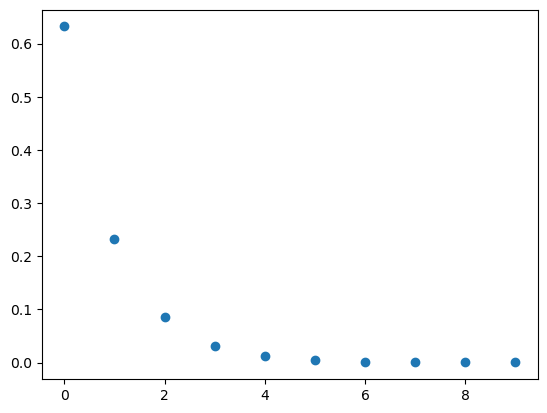

In [63]:

#plt.scatter(bidding_prices_i, adjusted_bids)
#plt.scatter(bidding_prices_i, normalized_bids)

plt.scatter(asking_prices_i, softmax_asks)
#plt.scatter(asking_prices_i, softmax(bidding_prices_i))

1.0

In [ ]:
# Agent comes to market with
# supply to sell
s = np.array([0, 0, 0])
# and or demand to buy
d = np.array([0, 1, 0])

# Sellers have an asking price
p_ask = np.array([1,1,1])

# Buyers have a bidding price
p_bid = np.array([1,1,1])

####

